# 信頼バンドの根探索 (`find_confidence_band`)

等間隔グリッドの代わりに、ブラケット＋幾何二分法でバンドの上下端を直接探す例。
最も広い 2σ で外側をブラケットし、各レベル (1σ/90%/2σ) の端を入れ子で詰める。

- `num_pseudo_data`: ブラケット段階の擬似データ数（粗くてよい）
- `n_pseudo_edge`: 端の二分法で使う擬似データ数（cutoff のノイズを抑えるため大きめ）
- `seed`: 固定すると各点が再現可能になり、二分法のジッターが減る


Optimization Complete.
Minimum chi-squared: 6.779129900985238e-05
Plot saved as scenario_bkg_b/flux_comparison_bkg_b.pdf


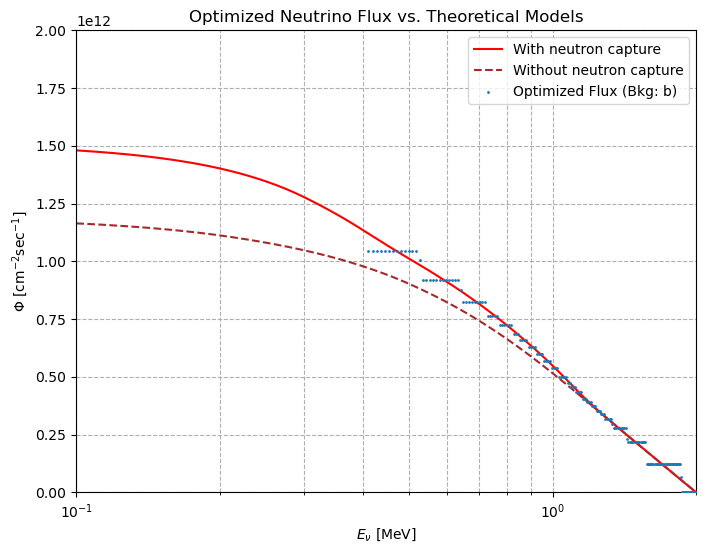

In [9]:
from neutrino_analysis_band import NeutrinoAnalysis

a = NeutrinoAnalysis(background_scenario='b', intervals='180',
                     GeV=0.6e16, solver='osqp')
a.optimize(a.data_vector)   # ベストフィットを先に求める (self.result を埋める)
result_b = a.optimize(a.data_vector)
print("\nOptimization Complete.")
print(f"Minimum chi-squared: {result_b.fun / a.c}")
# 3. Plot the primary result: the optimized flux vs. theory.
a.plot_flux_comparison(save = True)

## 複数インデックスのバンドを保存して重ねる

1. インデックスごとに `find_and_save_band` を実行し、`bands/` 配下に 1 ファイルずつ JSON で保存する。
2. `plot_flux_with_bands` で保存済みファイルを読み込み、`optimize` の最適フラックス（散布図）の上に各インデックスのバンドを誤差棒として重ねる。

`save_band` / `load_band` は JSON 形式（人が読める）。バンドの中心は保存時の `self.result.x[index]` なので、同じ `optimize` 結果の散布図とちょうど重なる。

In [2]:
# 複数インデックスでバンドを作り、インデックスごとに 1 ファイルへ保存
# 保存先は ./bands/band_bkg<scenario>_idx<NNN>.json
indices = [0, 1, 2, 3, 4, 5, 8, 13, 16, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 167]     # 走らせたいインデックス

for idx in indices:
    print(f'=== index {idx} ===')
    a.find_and_save_band(
        idx,
        outdir='scenario_bkg_b/bands',
        levels=(0.678, 0.954),
        num_pseudo_data=20,
        n_pseudo_edge=100,
        step=1.5,
        rel_tol=0.03,
        seed=42,
        n_jobs=-1,
        verbose=True,
    )

=== index 0 ===
[band idx=0] v0=1.0466e+12 (phys), bracketing with step=1.5
  upper bracket: 2.6824e+13
  lower bracket: 6.9775e+11
  level 0.678: [8.6553e+11, 1.3706e+13] (phys)
  level 0.954: [7.8210e+11, 2.4549e+13] (phys)
Band saved as scenario_bkg_b/bands/band_bkgb_idx000.json
=== index 1 ===
[band idx=1] v0=2.3090e+12 (phys), bracketing with step=1.5
  upper bracket: 1.1689e+13
  lower bracket: 6.8414e+11
  level 0.678: [8.0413e+11, 6.2832e+12] (phys)
  level 0.954: [7.3123e+11, 1.0973e+13] (phys)
Band saved as scenario_bkg_b/bands/band_bkgb_idx001.json
=== index 2 ===
[band idx=2] v0=4.5775e+12 (phys), bracketing with step=1.5
  upper bracket: 6.8662e+12
  lower bracket: 6.0280e+11
  level 0.678: [7.9535e+11, 4.6362e+12] (phys)
  level 0.954: [7.3479e+11, 6.6106e+12] (phys)
Band saved as scenario_bkg_b/bands/band_bkgb_idx002.json
=== index 3 ===
[band idx=3] v0=3.8398e+12 (phys), bracketing with step=1.5
  upper bracket: 5.7597e+12
  lower bracket: 5.0566e+11
  level 0.678: [7.9

Plot saved as scenario_bkg_b/flux_with_bands_bkg_b.pdf


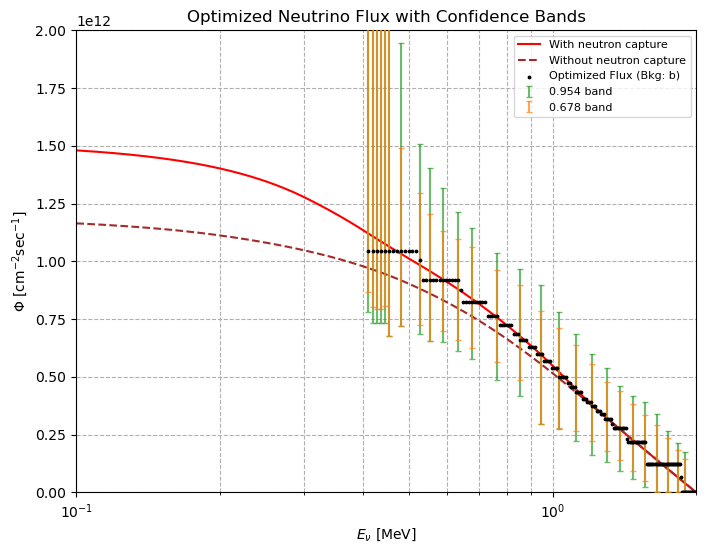

In [7]:
# 保存したバンドを読み込んで optimize 結果の上に重ねる
# band_files はグロブパターンでも、明示的なリストでもよい
a.plot_flux_with_bands(
    f'scenario_bkg_b/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # 表示するレベル (省略すると保存済み全レベル)
    save=True,
    ylim=(0, 3e13),                # 高フラックス側の裾まで見えるように
)
import matplotlib.pyplot as plt
#plt.yscale('log')
plt.ylim(0, 2e12)
plt.show()

Plot saved as scenario_bkg_b/flux_with_bands_bkg_b.pdf


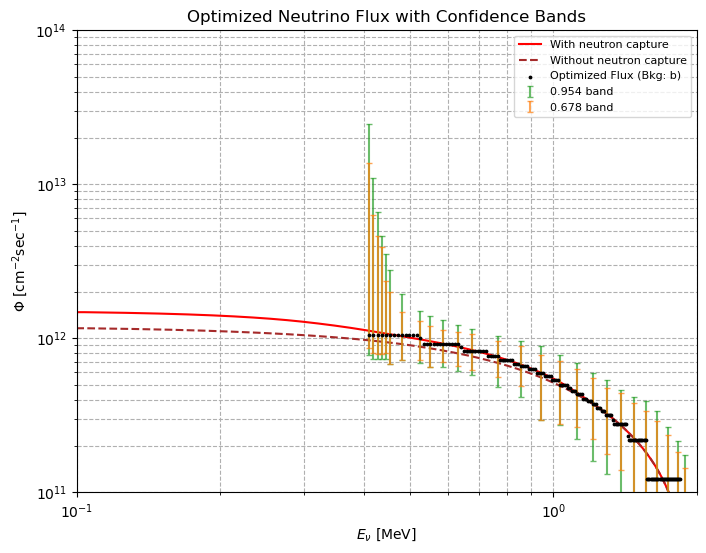

In [8]:
# 保存したバンドを読み込んで optimize 結果の上に重ねる
# band_files はグロブパターンでも、明示的なリストでもよい
a.plot_flux_with_bands(
    f'scenario_bkg_b/bands/band_bkg{a.background_scenario}_idx*.json',
    levels=(0.678, 0.954),   # 表示するレベル (省略すると保存済み全レベル)
    save=True,
    ylim=(0, 3e13),                # 高フラックス側の裾まで見えるように
)
import matplotlib.pyplot as plt
plt.yscale('log')
plt.ylim(1e11, 1e14)
plt.show()